In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [31]:
STUDY_NRS = ["s214696", "s224184", "s224223"]
# STUDY_NRS = ["s224184"]

MALE_END = "face_00.5.png"    # the adaptor at the male end of our continuum
FEMALE_END = "face_05.5.png"  # the adaptor at the female end
CONF = 0.95  # confidence level for the intervals in the figure

# The saved files have one row per condition and the ratings spread across one column each.
# Here we stack them into one long table with a single rating per row, which is easier to plot and to average over.
frames = []
for nr in STUDY_NRS:
    df = pd.read_csv(f"experiment_3_{nr}_1.csv")
    rating_cols = df.filter(like="rating_").columns
    long = df.melt(
        id_vars=["adapting_image", "test_image"],
        value_vars=rating_cols,
        value_name="rating",
    ).dropna(subset=["rating"])
    long["participant"] = nr
    frames.append(long)

data = pd.concat(frames, ignore_index=True)

# The filename of a test face contains the rating the model was asked to produce, so we pull it out and use it as the label on the x-axis.
data["test_level"] = data["test_image"].str[5:-4].astype(float)
data["rating"] = data["rating"].astype(float)

print(data.groupby(["participant", "adapting_image"])["rating"].count())

participant  adapting_image
s214696      face_00.5.png     15
             face_05.5.png     15
s224184      face_00.5.png     15
             face_05.5.png     15
s224223      face_00.5.png     15
             face_05.5.png     15
Name: rating, dtype: int64


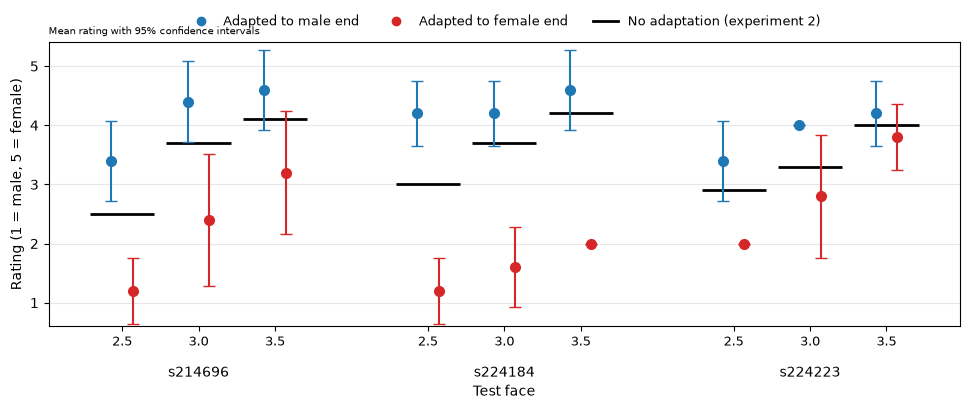

In [32]:
# The assignment asks for the ratings of the three test stimuli plotted separately for the two adaptation conditions, which is what the two coloured points in each column do.
# We also draw a baseline from experiment 2, where the same participant rated the same face with no adaptation at all, so the shift can be read in both directions instead of only as the gap between the two conditions.
# The experiment 2 ratings were collected under different circumstances - no fixation cross and no time limit on the face - so the baseline is the closest control we have rather than a clean one, and the figure caption should say so.
# A participant with no experiment 2 file simply gets no baseline line, and the rest of their column is drawn as usual.

levels = sorted(data["test_level"].unique())
colors = {MALE_END: "tab:blue", FEMALE_END: "tab:red"}
labels = {MALE_END: "Adapted to male end", FEMALE_END: "Adapted to female end"}


def mean_and_ci(values, conf=CONF):
    """Mean rating of one condition and the half-width of its confidence interval."""
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return values.mean(), 0.0
    se = values.std(ddof=1) / np.sqrt(len(values))
    return values.mean(), stats.t.ppf(1 - (1 - conf) / 2, len(values) - 1) * se


# The no-adaptation baseline is the mean of the ten ratings that participant gave the same face back in experiment 2.
baselines = {}
for nr in STUDY_NRS:
    try:
        exp2 = pd.read_csv(f"experiment_2_{nr}.csv")
    except FileNotFoundError:
        print(f"No experiment 2 file for {nr} - drawing that participant without a baseline")
        continue
    exp2["test_level"] = exp2["filename"].str[5:-4].astype(float)
    rating_cols = exp2.filter(like="rating_").columns
    for _, row in exp2.iterrows():
        baselines[(nr, row["test_level"])] = row[rating_cols].dropna().astype(float).mean()

# Each participant gets their three test faces side by side, with a blank slot between participants to keep the groups apart.
x_of = {}
x = 0
for nr in STUDY_NRS:
    for lvl in levels:
        x_of[(nr, lvl)] = x
        x += 1
    x += 1

fig, ax = plt.subplots(figsize=(2.6 * len(STUDY_NRS) + 2, 4.2))

for nr in STUDY_NRS:
    for lvl in levels:
        x = x_of[(nr, lvl)]

        base = baselines.get((nr, lvl))
        if base is not None:
            ax.hlines(base, x - 0.42, x + 0.42, color="black", linewidth=2, zorder=2)

        for offset, adaptor in [(-0.14, MALE_END), (0.14, FEMALE_END)]:
            values = data[(data.participant == nr) & (data.test_level == lvl)
                          & (data.adapting_image == adaptor)]["rating"]
            mean, half = mean_and_ci(values)
            ax.errorbar(x + offset, mean, yerr=half, fmt="o", markersize=7,
                        color=colors[adaptor], capsize=4, zorder=3)

ax.set_xticks([x_of[(nr, lvl)] for nr in STUDY_NRS for lvl in levels])
ax.set_xticklabels([f"{lvl:.1f}" for _ in STUDY_NRS for lvl in levels], fontsize=9)

# The participant ID goes underneath their own group of three, so the x-axis does not have to repeat it on every tick.
for nr in STUDY_NRS:
    centre = np.mean([x_of[(nr, lvl)] for lvl in levels])
    ax.annotate(nr, (centre, -0.14), xycoords=("data", "axes fraction"),
                ha="center", va="top", fontsize=10)

ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylim(0.6, 5.4)
ax.set_ylabel("Rating (1 = male, 5 = female)")
ax.set_xlabel("Test face", labelpad=26)
ax.grid(axis="y", alpha=0.3)

handles = [plt.Line2D([], [], marker="o", linestyle="", color=colors[MALE_END]),
           plt.Line2D([], [], marker="o", linestyle="", color=colors[FEMALE_END]),
           plt.Line2D([], [], color="black", linewidth=2)]
ax.legend(handles, [labels[MALE_END], labels[FEMALE_END], "No adaptation (experiment 2)"],
          fontsize=9, loc="lower center", bbox_to_anchor=(0.5, 1.01),
          ncol=3, frameon=False)
ax.set_title(f"Mean rating with {CONF:.0%} confidence intervals", loc="left", fontsize=7)

plt.tight_layout()
plt.savefig("experiment3_shift_from_baseline.png", dpi=200)
plt.show()

In [ ]:
# The prediction is that perception is pushed AWAY from whatever was adapted to.
# A positive difference below means the after-effect went the predicted way.

rows = []
for (nr, lvl), group in data.groupby(["participant", "test_level"]):
    after_male = group[group.adapting_image == MALE_END]["rating"].mean()
    after_female = group[group.adapting_image == FEMALE_END]["rating"].mean()
    base = baselines.get((nr, lvl))

    rows.append({
        "participant": nr,
        "test face": f"{lvl:.1f}",
        "no adaptation (exp2)": base,
        "after male adapt": after_male,
        "after female adapt": after_female,
        "shift towards female": after_male - base if base is not None else np.nan,
        "shift towards male": after_female - base if base is not None else np.nan,
        "difference": after_male - after_female,
        "as predicted": "yes" if after_male > after_female else "no",
    })

means = pd.DataFrame(rows)
means = means.sort_values(["test face", "participant"])

print(means.round(2).to_string(index=False))
print(f"\n{(means['difference'] > 0).sum()} of {len(means)} test-face/participant combinations "
      "went in the predicted direction")

participant test face  no adaptation (exp2)  after male adapt  after female adapt  shift towards female  shift towards male  difference as predicted
    s214696       2.5                   2.5               3.4                 1.2                   0.9                -1.3         2.2          yes
    s224184       2.5                   3.0               4.2                 1.2                   1.2                -1.8         3.0          yes
    s224223       2.5                   2.9               3.4                 2.0                   0.5                -0.9         1.4          yes
    s214696       3.0                   3.7               4.4                 2.4                   0.7                -1.3         2.0          yes
    s224184       3.0                   3.7               4.2                 1.6                   0.5                -2.1         2.6          yes
    s224223       3.0                   3.3               4.0                 2.8                   0.7   